<a href="https://colab.research.google.com/github/lillymitch/organized_archives/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preparation: Training Transforms

In [1]:
## Training Transforms
from torchvision import transforms

train_processor = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_processor = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Import and Condense Dataset

In [14]:
import kagglehub

#downloads the WikiArt 25k dataset from Kaggle Hub
#returns the path to the downloaded dataset.
path = kagglehub.dataset_download("trungit/wikiart25k")

print(path)

Using Colab cache for faster access to the 'wikiart25k' dataset.
/kaggle/input/wikiart25k


In [19]:
import os
import shutil

#Defines the path for the small dataset to be created locally
small_dataset_path = "/content/wikiart_small"

#Lists art classes to include in the small dataset
selected_classes = [
    "Impressionism",
    "Cubism",
    "Baroque",
    "Pop_Art",
    "Ukiyo_e",
    "Realism"
]

#Sets the maximum number of images to select per class
max_per_class = 20

#Creates the base directory for the small dataset if it doesn't exist
os.makedirs(small_dataset_path, exist_ok=True)

#condense the dataset
for class_name in selected_classes:

    source_folder = os.path.join(path, class_name)
    target_folder = os.path.join(small_dataset_path, class_name)
    os.makedirs(target_folder, exist_ok=True) #target class directory if doesn't exist
    image_files = os.listdir(source_folder)[:max_per_class]

    #copies each selected image file to the new small dataset directory
    for image_file in image_files:
        shutil.copy(
            os.path.join(source_folder, image_file),
            os.path.join(target_folder, image_file)
        )

print("small dataset created")

small dataset created


In [20]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

#ImageFolder dataset created from the condensed small dataset
dataset = ImageFolder(
    root=small_dataset_path,
    transform=train_processor
)

#structural test
print(len(dataset))
print(dataset.classes)

print("dataset size:", len(dataset))
print("classes:", dataset.classes)

120
['Baroque', 'Cubism', 'Impressionism', 'Pop_Art', 'Realism', 'Ukiyo_e']
dataset size: 120
classes: ['Baroque', 'Cubism', 'Impressionism', 'Pop_Art', 'Realism', 'Ukiyo_e']


## Example Images from Each Class

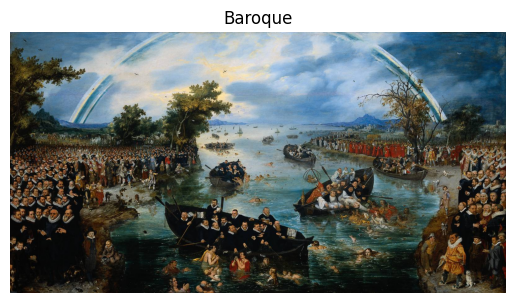

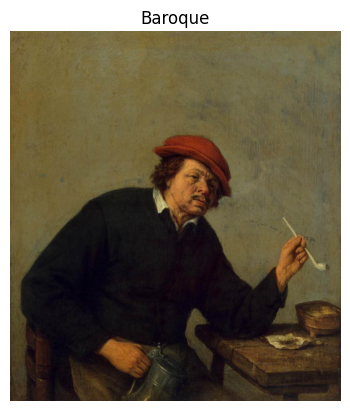

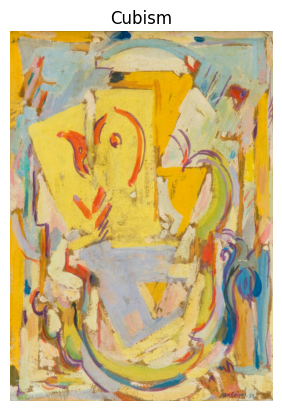

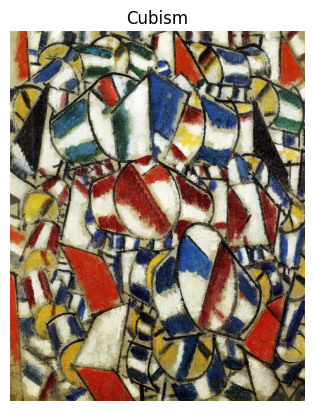

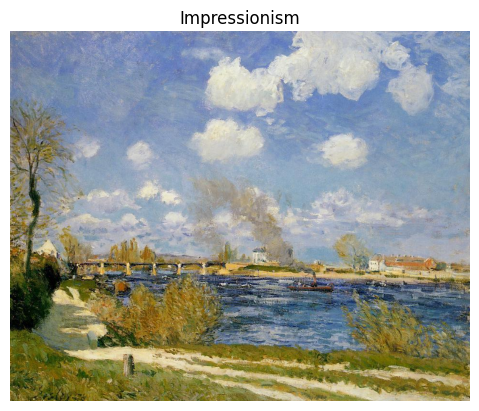

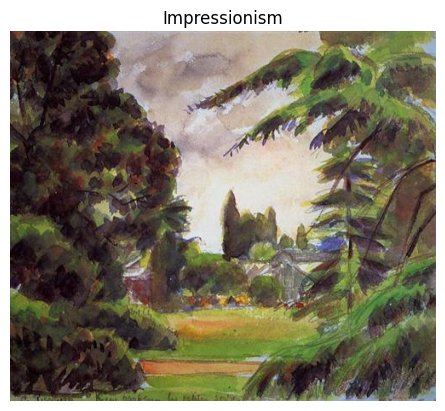

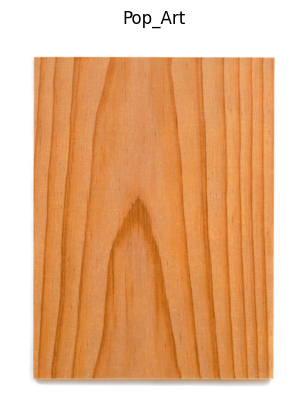

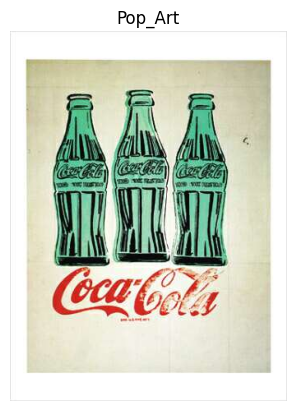

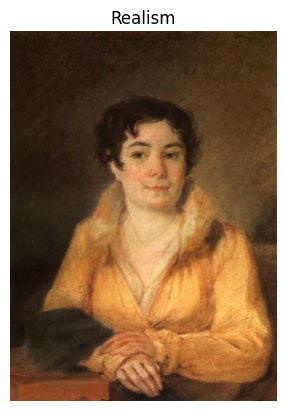

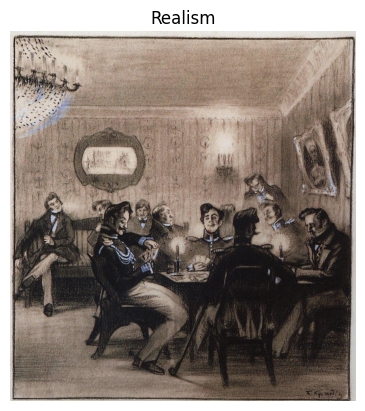

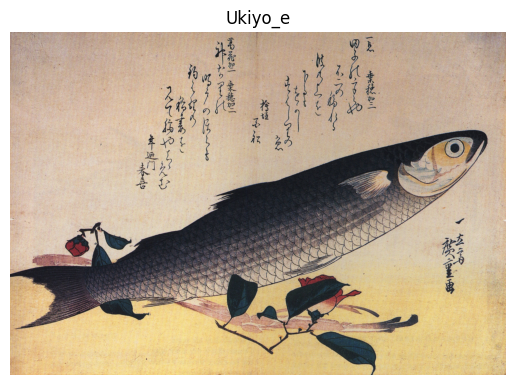

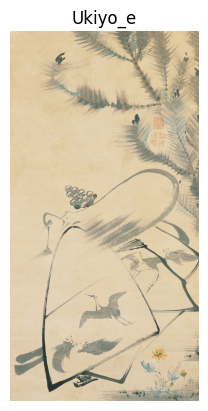

In [33]:
#code source for just this section: ChatGPT

# Baroque
from PIL import Image
import matplotlib.pyplot as plt

file_path, label = dataset.samples[0]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

file_path, label = dataset.samples[1]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()


# Cubism

file_path, label = dataset.samples[20]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

file_path, label = dataset.samples[21]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()


# Impressionism

file_path, label = dataset.samples[40]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

file_path, label = dataset.samples[41]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()


# Pop Art

file_path, label = dataset.samples[60]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

file_path, label = dataset.samples[61]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()


# Realism

file_path, label = dataset.samples[80]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

file_path, label = dataset.samples[81]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()


# Ukiyo_e

file_path, label = dataset.samples[100]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

file_path, label = dataset.samples[101]

img = Image.open(file_path)

plt.imshow(img)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

In [34]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

#Defines the split ratios for training, validation, and testing
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

#Splits the dataset randomly into training, validation, and test sets
train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

#Creates DataLoaders for each dataset split
#train_loader shuffles data for better training dynamics
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
#val_loader and test_loader do not need shuffling
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

#Gets the number of classes from the dataset (used for model configuration)
num_classes = len(dataset.classes)

# Data Loading

In [22]:
num_classes = len(dataset.classes)

## ResNet18 Transfer Learning

In [9]:
## ResNet18 transfer learning
from torchvision import models
import torch.nn as nn

def build_transfer_model(num_classes):
  model = models.resnet18(pretrained=True)

  # freeze most layers
  for param in model.parameters():
    param.requires_grad = False

  # unfreeze last layer block (for better performance)
  for param in model.layer4.parameters():
    param.requires_grad = True

  # replace final layer
  model.fc = nn.Linear(model.fc.in_features, num_classes)

  return model

## Model Architecture: Logistic Regression

In [10]:
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Define a simple Logistic Regression model for image data
class LogisticRegression(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Input image is 3x224x224. Flatten to 3 * 224 * 224 features.
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(3 * 224 * 224, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.linear(x)

# Define the cross-entropy loss function
def cross_entropy_loss(outputs, targets):
    return F.cross_entropy(outputs, targets)

## Optimizer Comparison Function

In [11]:
def test_optimizer(model_builder_function, n_epochs=10):
    # num_classes, cross_entropy_loss, and train_loader are
    # expected to be available globally or passed in.

    small_alpha = 1e-6
    large_alpha = 2e-5

    optimizers_config = {
        "Gradient descent": {'lr': small_alpha, 'momentum': 0.0, 'optimizer_class': torch.optim.SGD},
        "Gradient descent (high learning rate)": {'lr': large_alpha, 'momentum': 0.0, 'optimizer_class': torch.optim.SGD},
        "Momentum": {'lr': small_alpha, 'momentum': 0.9, 'optimizer_class': torch.optim.SGD},
        "Momentum (high learning rate)": {'lr': large_alpha, 'momentum': 0.9, 'optimizer_class': torch.optim.SGD},
        "Adam": {'lr': small_alpha, 'optimizer_class': torch.optim.Adam},
        "Adam (high learning rate)": {'lr': large_alpha, 'optimizer_class': torch.optim.Adam},
    }

    losses_dict = {}

    for name, config in optimizers_config.items():
        # Re-initialize the model for each optimizer test to ensure a clean slate
        model = model_builder_function() # Build the model using the provided function

        # Create optimizer instance, passing model.parameters()
        optimizer_params = {'lr': config['lr']}
        if 'momentum' in config:
            optimizer_params['momentum'] = config['momentum']
        optimizer = config['optimizer_class'](model.parameters(), **optimizer_params)

        # Sanity check: print loss before first epoch
        model.eval()
        with torch.no_grad():

            total_loss = 0
            for images, labels in train_loader:
              y_pred = model(images)
              # Calculate loss
              loss = cross_entropy_loss(y_pred, labels)
              total_loss += loss.item() * images.size(0)
            avg_epoch_loss = total_loss / len(train_loader.dataset)
            print(f"Initial loss for {name}: {avg_epoch_loss}")


        losses_dict[name] = []
        losses_dict[name].append(avg_epoch_loss)
        for epoch in range(n_epochs):
            model.train()
            total_loss = 0
            # Iterate over the train_loader to get batches of images and labels
            for images, labels in train_loader:
              y_pred = model(images)

              print("y_pred stats:")
              print("min:", y_pred.min().item())
              print("max:", y_pred.max().item())
              print("mean:", y_pred.mean().item())
              print("labels:", labels[:5])

              loss = cross_entropy_loss(y_pred, labels)
              print("loss:", loss.item())

              break  # only check first batch

            avg_epoch_loss = total_loss / len(train_loader.dataset) # Average loss for the epoch
            losses_dict[name].append(avg_epoch_loss)

    fig, axarr = plt.subplots(1, 3, figsize = (12, 4), sharey=True)
    for name, losses in losses_dict.items():
        if "Gradient descent" in name:
            i = 0
        elif "Momentum" in name:
            i = 1
        else:
            i = 2

        if "high learning rate" in name:
            label = name.split(" ")[0] + " (high lr)"
            alpha_val = large_alpha
        else:
            label = name.split(" ")[0]
            alpha_val = small_alpha

        axarr[i].plot(losses, label=r"$\alpha = $" + f"{alpha_val:.0e}", linestyle = '-' if "high learning rate" in name else '--')
        axarr[i].set_title(name.split(" ")[0])
        if i == 2: # Only show legend on the last subplot
            axarr[i].legend()

        if i == 0:
            axarr[i].set_ylabel("Loss")
    for ax in axarr:
        ax.set_xlabel("Epoch")
        ax.grid(True)

    plt.suptitle("Training Loss for Different Optimizers")
    plt.tight_layout()
    plt.show()

## Training Loop Function

In [12]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import requests
from io import BytesIO
#training loop
def train_model(model, train_loader, val_loader, optimizer,cross_entropy_loss, num_epochs = 1000):

  #GPU type
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  #load model to gpu
  model.to(device)
  #for debugging
  history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

  for epoch in range(num_epochs):
    model.train()

    total_train_loss = 0
    correct_train_predictions = 0
    total_train_elements = 0

    for images, labels in train_loader:

      #move images and labels to same gpuf
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad() #prevents accumulating previous gradient values

      # Forward pass
      outputs = model(images)
      #params: predicted outputs(images) and true lables
      loss = cross_entropy_loss(outputs, labels)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      #aggregate loss, which is scaled by batch size
      total_train_loss += loss.item() * images.size(0)

      #finds max along dimension 1 (across classes)
      _, indices = torch.max(outputs, 1)

      #count how many predictions are correct
      correct_train_predictions += (indices == labels).sum().item()
      total_train_elements += labels.size(0)

    #training accuracy
    total_train_loss /= len(train_loader.dataset)

    #calculate accuracy
    train_accuracy = correct_train_predictions / total_train_elements
    history['train_loss'].append(total_train_loss)
    history['train_acc'].append(train_accuracy)
    print(train_accuracy)

    #repeat the same thing for validation data
    total_val_loss = 0
    correct_val_predictions = 0
    total_val_elements = 0

    #evaluating model (validation)
    model.eval()
    with torch.no_grad():
      for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        loss = cross_entropy_loss(outputs, labels)
        total_val_loss += loss.item() * images.size(0)

        _, indices = torch.max(outputs, 1)
        correct_val_predictions += (indices == labels).sum().item()
        total_val_elements += labels.size(0)

      #validation accuracy
      total_val_loss /= len(val_loader.dataset)
      val_accuracy = correct_val_predictions / total_val_elements
      history['val_loss'].append(total_val_loss)
      history['val_acc'].append(val_accuracy)
      print(val_accuracy)

## Main Execution Block

Initial loss for Gradient descent: 2.0331288065229143
y_pred stats:
min: -2.090848445892334
max: 1.8527518510818481
mean: 0.06330474466085434
labels: tensor([0, 3, 2, 3, 0])
loss: 2.0263283252716064
Initial loss for Gradient descent (high learning rate): 1.8603530611310686
y_pred stats:
min: -1.6424949169158936
max: 1.7648953199386597
mean: 0.0189566221088171
labels: tensor([1, 4, 2, 1, 1])
loss: 1.97769296169281
Initial loss for Momentum: 2.071227857044765
y_pred stats:
min: -2.1256890296936035
max: 2.1089577674865723
mean: -0.03830154985189438
labels: tensor([4, 5, 1, 4, 1])
loss: 2.102919816970825
Initial loss for Momentum (high learning rate): 2.0163385300409224
y_pred stats:
min: -2.121392011642456
max: 1.7285140752792358
mean: -0.1257818043231964
labels: tensor([3, 3, 0, 4, 4])
loss: 2.10003399848938
Initial loss for Adam: 2.0066124541418895
y_pred stats:
min: -1.519551157951355
max: 1.2519028186798096
mean: -0.009344573132693768
labels: tensor([3, 1, 0, 4, 4])
loss: 1.9540846347

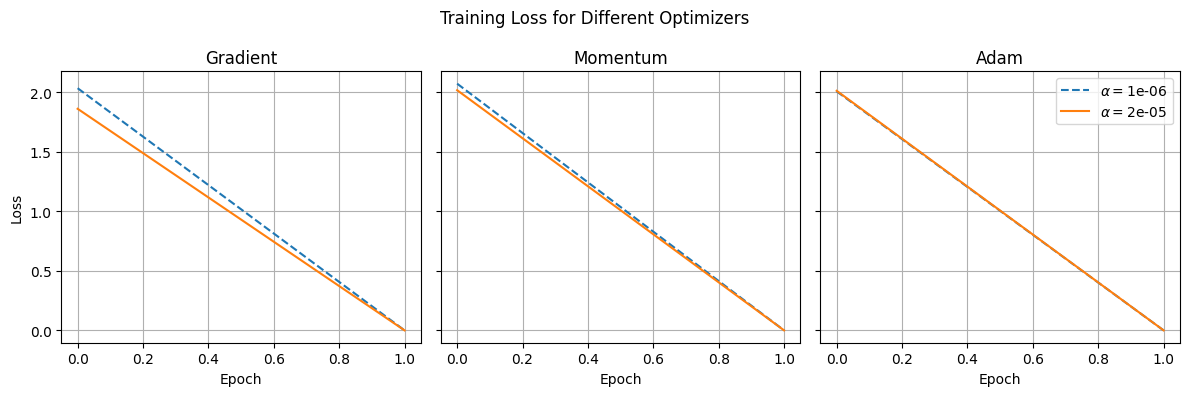

In [13]:
model_builder_for_test = lambda: LogisticRegression(num_classes=num_classes)
#first test optimizer to use
test_optimizer(model_builder_for_test, n_epochs=1)

In [27]:
if __name__ == "__main__":
  num_classes = len(label_map)
  model = LogisticRegression(num_classes)